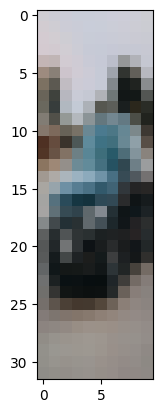

In [2]:
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms import Resize

image = Image.open("car.png")
resize = Resize((32, 10))
resized_image = resize(image)
plt.imshow(resized_image) 

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.77MB/s]


Extracting data/FashionMNIST\raw\train-images-idx3-ubyte.gz to data/FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 501kB/s]


Extracting data/FashionMNIST\raw\train-labels-idx1-ubyte.gz to data/FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 6.69MB/s]


Extracting data/FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data/FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.11MB/s]


Extracting data/FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data/FashionMNIST\raw



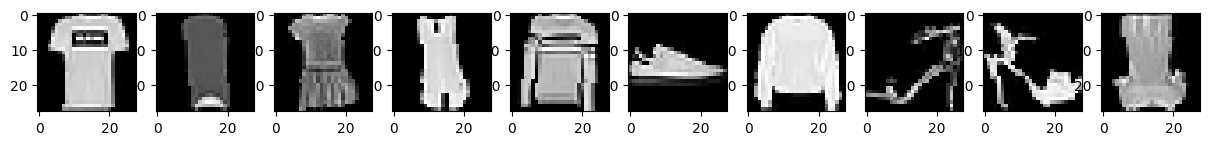

In [3]:
from torchvision.datasets import FashionMNIST
from matplotlib import pyplot as plt
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose

transforms = Compose([RandomHorizontalFlip(p=0.3), RandomVerticalFlip(p=0.3), RandomRotation([-10, 10])])


# Переменная для пайплайна аугментации

dataset = FashionMNIST(root ='data/', download=True, transform=transforms)

# Визуализация
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = dataset[index]
    plt.subplot(1, 10, index)
    plt.imshow(image, cmap='gray') 

In [11]:
import torch
import torchvision
from torchsummary import summary
from torchvision.models import resnet50

model = resnet50(weights='IMAGENET1K_V2')
model = model.cpu()

summary(model, input_size=(3, 224, 224), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [17]:
import timm
model = timm.create_model('tf_mobilenetv3_small_100', checkpoint_path='tf_mobilenetv3_small_100-37f49e2b.pth')
# Проверка
print(model) 

d:\Projects\praktikum\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MobileNetV3(
  (conv_stem): Conv2dSame(3, 16, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): Hardswish()
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2dSame(16, 16, kernel_size=(3, 3), stride=(2, 2), groups=16, bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): ReLU(inplace=True)
          (conv_expand): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (gate): Hardsigmoid()
        )
        (conv_pw): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
         

In [28]:
from torchvision.models import mobilenet_v3_small
import torch.nn as nn

model = mobilenet_v3_small(weights='IMAGENET1K_V1') 

binary_classifier = nn.Sequential(
    nn.Linear(in_features=576, out_features=1024, bias=True),
    nn.Hardswish(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=1024, out_features=1, bias=True),
    nn.Sigmoid()
) 
model.classifier = binary_classifier
print(model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [29]:
from torchvision.models import resnet50
import torch.nn as nn

model = resnet50(weights='IMAGENET1K_V2')

model.fc = nn.Linear(in_features=2048, out_features=10, bias=True)

# Проверка
print(model) 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [34]:
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.transforms import ToTensor, Normalize

# Предобработка и аугментация для обучающего датасета
train_transforms = Compose([
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5]), 
    ToTensor(),
    Normalize((0.5), (0.5))
])

# Предобработка для проверочного датасета
test_transforms = Compose([
    ToTensor(),
    Normalize((0.5), (0.5))
]) 

In [31]:
from torchvision.datasets import FashionMNIST

train_dataset = FashionMNIST(root ='data/', # куда скачать
                             download=True, 
                             transform=train_transforms, 
                             train=True)
val_dataset = FashionMNIST(root ='data/',
                           download=True, 
                           transform=test_transforms,
                           train=False)

print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset)) 

Количество изображений в train: 60000
Количество изображений в val: 10000


In [37]:
from torch.utils.data import DataLoader

batch_size = 16
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False) 

T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal
T-shirt/top


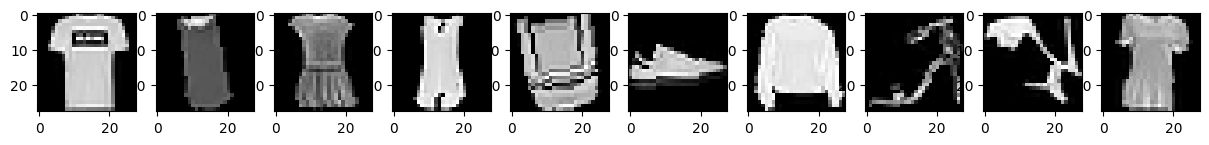

In [38]:
# Названия классов из датасета
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress',
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image[0], cmap='gray') 

Количество изображений в train: 60000
Количество изображений в val: 10000
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal
T-shirt/top


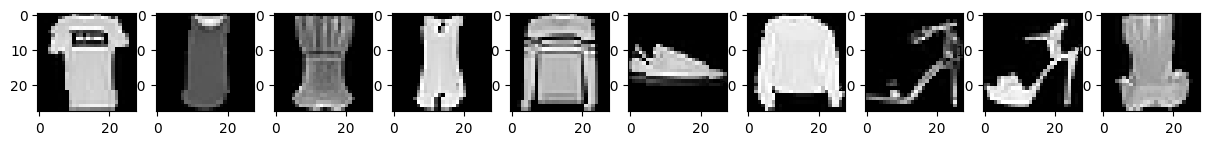

In [39]:
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.transforms import ToTensor, Normalize
from torchvision.datasets import FashionMNIST
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

train_transforms = Compose([
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5]),
    ToTensor(),
    Normalize((0.5), (0.5))
])

test_transforms = Compose([
    ToTensor(),
    Normalize((0.5), (0.5))
])

train_dataset = FashionMNIST(root ='data/', 
                             download=True, 
                             transform=train_transforms, 
                             train=True)
val_dataset = FashionMNIST(root ='data/',
                           download=True, 
                           transform=test_transforms,
                           train=False)

batch_size = 16
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False)

print("Количество изображений в train:", len(train_dataset))
print("Количество изображений в val:", len(val_dataset))

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress',
           'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image[0], cmap='gray') 

In [47]:
import torch.nn as nn

class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding='same')
        self.conv2 = nn.Conv2d(32, 64, 3, padding='same')
        self.pool = nn.MaxPool2d(2, 2)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.pool(x)

        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = FashionClassifier() 

import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    for batch_index, data in enumerate(train_loader):
        # Извлечение батча
        inputs, labels = data
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model(inputs)
        # Подсчет ошибки
        loss = criterion(outputs, labels)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        # Суммирование ошибки за последние 100 батчей
        running_loss += loss.item()
        if batch_index % 100 == 99:
            last_loss = running_loss / 100. # средняя ошибка за 100 батчей
            print(f'Эпоха: {epoch_index}, батч: {batch_index}, ошибка {last_loss}')
            running_loss = 0.

    return last_loss 

In [49]:
import torch

EPOCHS = 10

best_vloss = 1e5

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    # Перевод модели в режим обучения
    model.train(True)
    # Эпоха обучения
    avg_loss = train_one_epoch(epoch)

    # Перевод модели в режим валидации
    model.eval()
    running_vloss = 0.0

    # Валидация
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = criterion(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)

    # Сохранение лучшей модели
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'fashion_classifier_{epoch}.pt'
        torch.save(model.state_dict(), model_path)

    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}') 

Эпоха 0
Эпоха: 0, батч: 99, ошибка 0.631862068027258
Эпоха: 0, батч: 199, ошибка 0.5639775188267231
Эпоха: 0, батч: 299, ошибка 0.5758925837278366
Эпоха: 0, батч: 399, ошибка 0.5499427580833435
Эпоха: 0, батч: 499, ошибка 0.5356388774514198
Эпоха: 0, батч: 599, ошибка 0.5632144072651863
Эпоха: 0, батч: 699, ошибка 0.5231837537884713
Эпоха: 0, батч: 799, ошибка 0.5378028076142073
Эпоха: 0, батч: 899, ошибка 0.5617562641203403
Эпоха: 0, батч: 999, ошибка 0.572450821697712
Эпоха: 0, батч: 1099, ошибка 0.5852425856888295
Эпоха: 0, батч: 1199, ошибка 0.5754892648756504
Эпоха: 0, батч: 1299, ошибка 0.5356702373921871
Эпоха: 0, батч: 1399, ошибка 0.5851540645956993
Эпоха: 0, батч: 1499, ошибка 0.496432089060545
Эпоха: 0, батч: 1599, ошибка 0.5346344974637032
Эпоха: 0, батч: 1699, ошибка 0.5242023508250714
Эпоха: 0, батч: 1799, ошибка 0.5685548560321331
Эпоха: 0, батч: 1899, ошибка 0.5448527736961841
Эпоха: 0, батч: 1999, ошибка 0.5209588382393122
Эпоха: 0, батч: 2099, ошибка 0.557561704665422

In [53]:
model_path = 'fashion_classifier_1.pt'
model = FashionClassifier()
model.load_state_dict(torch.load(model_path, weights_only=True)) 

import torch

labels_predicted = []
labels_true = []

with torch.no_grad():
    for data in val_loader:
        images, labels = data

        outputs = model(images)
        # argmax по всем примерам, так как torch.max возвращает два параметра
        # максимальные значения в выборке и позиции, на которых они находятся (argmax)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())


from sklearn.metrics import classification_report

print(classification_report(labels_true, labels_predicted, target_names=classes))

              precision    recall  f1-score   support

 T-shirt/top       0.76      0.79      0.77      1000
     Trouser       0.98      0.95      0.96      1000
    Pullover       0.72      0.83      0.77      1000
       Dress       0.71      0.91      0.80      1000
        Coat       0.70      0.68      0.69      1000
      Sandal       0.94      0.91      0.93      1000
       Shirt       0.71      0.41      0.52      1000
     Sneaker       0.91      0.92      0.91      1000
         Bag       0.93      0.94      0.94      1000
  Ankle boot       0.91      0.94      0.92      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.82     10000
weighted avg       0.83      0.83      0.82     10000

